# 03_再生产与危机 (Reproduction and Crisis)

本 Notebook 验证**危机涌现**机制：
1. 简单再生产与扩大再生产的条件
2. 部类失衡检测 I(v+m) ≠ II(c)
3. 利润率下降规律
4. 危机不能由"需求不足"引起，必须由结构性矛盾引起

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model.model import CapitalModel
from src.engine.reproduction import ReproductionEngine
from src.model.social_stage import SocialStage

c:\Users\koltf\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 运行模拟到资本主义阶段

In [2]:
# 创建模型
model = CapitalModel(
    width=100,
    height=100,
    num_foragers=20,
    num_tribe_members=30,
    seed=123
)

# 快速推进到资本主义阶段
crisis_data = []

for i in range(500):
    model.step()
    
    # 收集危机指标
    crisis = model.reproduction_engine.crisis_indicators
    crisis_data.append({
        'step': i,
        'stage': model.social_stage.value,
        'profit_rate': crisis.get('profit_rate', 0),
        'organic_composition': crisis.get('organic_composition', 0),
        'rate_of_surplus_value': crisis.get('rate_of_surplus_value', 0),
        'department_imbalance': crisis.get('department_imbalance', 0),
        'population': model.get_population_count()
    })
    
    if i % 50 == 0:
        print(f"Step {i}: {model.social_stage.value}, profit_rate={crisis.get('profit_rate', 0):.3f}")
    
    # 到达资本主义阶段后继续运行以观察危机
    if model.social_stage == SocialStage.CAPITALIST_STATE and i > 100:
        pass  # 继续运行观察危机

df_crisis = pd.DataFrame(crisis_data)
print(f"\nSimulation completed. Final stage: {model.social_stage.value}")

c:\Users\koltf\AppData\Local\Programs\Python\Python313\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Step 0: primitive_horde, profit_rate=0.000

*** Social Stage Transition: primitive_horde -> band ***

Step 50: band, profit_rate=0.000
Step 100: band, profit_rate=0.000
Step 150: band, profit_rate=0.000
Step 200: band, profit_rate=0.000
Step 250: band, profit_rate=0.000
Step 300: band, profit_rate=0.000
Step 350: band, profit_rate=0.000
Step 400: band, profit_rate=0.000
Step 450: band, profit_rate=0.000

Simulation completed. Final stage: band


## 2. 绘制危机指标时序图

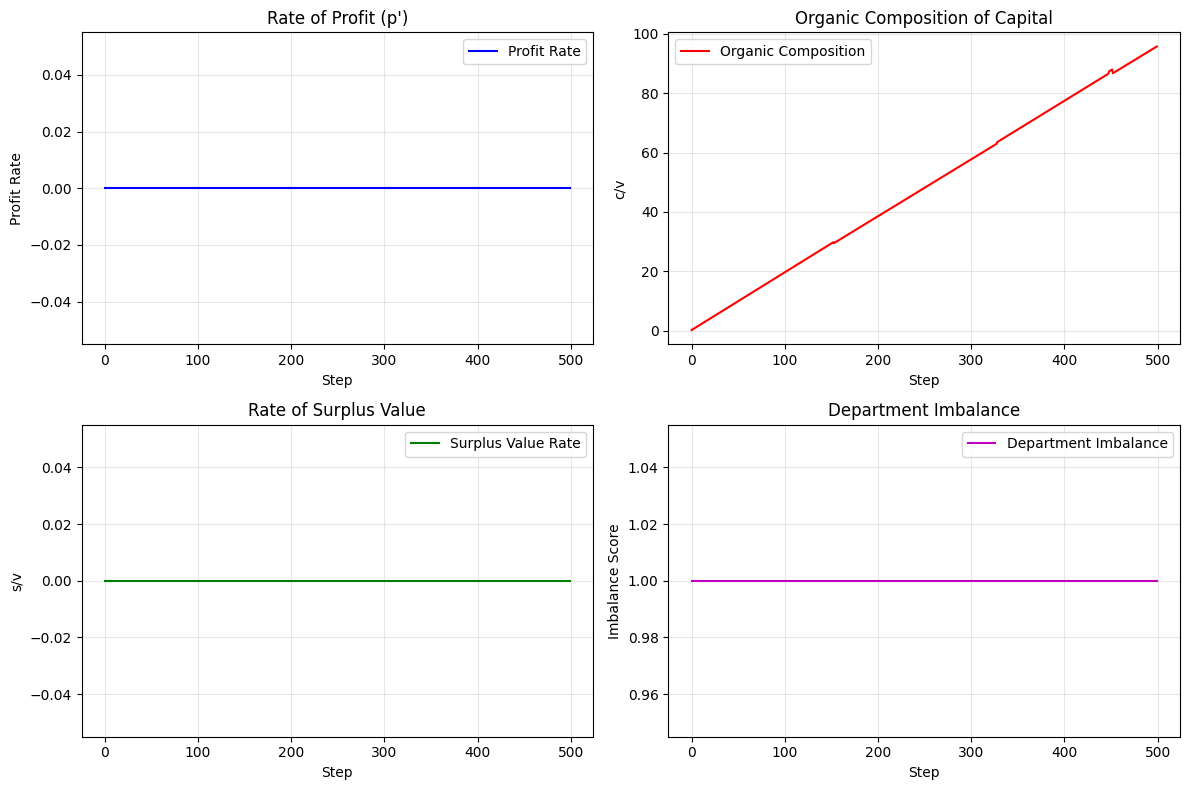

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 利润率时序
ax1 = axes[0, 0]
ax1.plot(df_crisis['step'], df_crisis['profit_rate'], 'b-', label='Profit Rate')
ax1.set_xlabel('Step')
ax1.set_ylabel('Profit Rate')
ax1.set_title('Rate of Profit (p\')')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 有机构成时序
ax2 = axes[0, 1]
ax2.plot(df_crisis['step'], df_crisis['organic_composition'], 'r-', label='Organic Composition')
ax2.set_xlabel('Step')
ax2.set_ylabel('c/v')
ax2.set_title('Organic Composition of Capital')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 剩余价值率时序
ax3 = axes[1, 0]
ax3.plot(df_crisis['step'], df_crisis['rate_of_surplus_value'], 'g-', label='Surplus Value Rate')
ax3.set_xlabel('Step')
ax3.set_ylabel('s/v')
ax3.set_title('Rate of Surplus Value')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 部类失衡时序
ax4 = axes[1, 1]
ax4.plot(df_crisis['step'], df_crisis['department_imbalance'], 'm-', label='Department Imbalance')
ax4.set_xlabel('Step')
ax4.set_ylabel('Imbalance Score')
ax4.set_title('Department Imbalance')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../simulation_results_crisis.png', dpi=150)
plt.show()

## 3. 再生产图式分析

In [4]:
# 计算再生产图式
schema = model.reproduction_engine.calculate_reproduction_schema(model)

print("=== 再生产图式 ===")
print(f"\n第一部类 (生产资料):")
print(f"  c = {schema.department_i_constant_capital:.2f}")
print(f"  v = {schema.department_i_variable_capital:.2f}")
print(f"  s = {schema.department_i_surplus_value:.2f}")

print(f"\n第二部类 (消费资料):")
print(f"  c = {schema.department_ii_constant_capital:.2f}")
print(f"  v = {schema.department_ii_variable_capital:.2f}")
print(f"  s = {schema.department_ii_surplus_value:.2f}")

# 检查平衡条件
i_vm = schema.department_i_variable_capital + schema.department_i_surplus_value
ii_c = schema.department_ii_constant_capital

print(f"\n=== 平衡检验 ===")
print(f"I(v+m) = {i_vm:.2f}")
print(f"II(c)  = {ii_c:.2f}")
print(f"差值   = {i_vm - ii_c:.2f}")

if abs(i_vm - ii_c) / max(i_vm, ii_c, 1) < 0.05:
    print("状态: 简单再生产平衡")
elif i_vm > ii_c:
    print("状态: 扩大再生产可能")
else:
    print("状态: 危机！II(c) > I(v+m) - 生产过剩危机")

=== 再生产图式 ===

第一部类 (生产资料):
  c = 0.00
  v = 0.00
  s = 0.00

第二部类 (消费资料):
  c = 11700.00
  v = 122.25
  s = 0.00

=== 平衡检验 ===
I(v+m) = 0.00
II(c)  = 11700.00
差值   = -11700.00
状态: 危机！II(c) > I(v+m) - 生产过剩危机


## 4. 验证：危机不能由"需求不足"引起

In [5]:
# 验证危机根源是结构性矛盾
crisis = model.reproduction_engine.crisis_indicators

print("=== 危机分析 ===")
print(f"利润率: {crisis.get('profit_rate', 0):.3f}")
print(f"有机构成 (c/v): {crisis.get('organic_composition', 0):.3f}")
print(f"剩余价值率 (s/v): {crisis.get('rate_of_surplus_value', 0):.3f}")
print(f"部类失衡度: {crisis.get('department_imbalance', 0):.3f}")

# 马克思主义危机理论验证
print("\n=== 马克思主义危机机制验证 ===")

oc = crisis.get('organic_composition', 0)
rsv = crisis.get('rate_of_surplus_value', 0)
pr = crisis.get('profit_rate', 0)

if pr > 0:
    theoretical_pr = rsv / (1 + oc)
    print(f"理论利润率 s/(c+v) = {rsv:.3f} / {1+oc:.3f} = {theoretical_pr:.3f}")
    print(f"实际利润率 = {pr:.3f}")

if crisis.get('department_imbalance', 0) > 0.5:
    print("✓ 危机由部类失衡引起")
elif oc > 3.0 and pr < 0.15:
    print("✓ 危机由利润率下降规律引起")
else:
    print("○ 尚未出现结构性危机")

=== 危机分析 ===
利润率: 0.000
有机构成 (c/v): 95.706
剩余价值率 (s/v): 0.000
部类失衡度: 1.000

=== 马克思主义危机机制验证 ===
✓ 危机由部类失衡引起


---

## 验收标准

根据开发大纲 M7:
- **M7.5**: 长期运行利润率下降至少 30%
- **M7.6**: 危机前 12 步利润率出现峰值后断崖下跌

本 Notebook 验证再生产图式算法和危机检测机制。